# Fase 6c — Diagnóstico del modo de fallo con XGBoost (vs CNN)
### TFM: Arquitectura de Mantenimiento Predictivo

La Fase 6 hizo el diagnóstico con una CNN 1D (39% por ciclo, 57% agrupado). Aquí probamos
la alternativa tabular: un **XGBoost multiclase** sobre el mismo pipeline de características
de la prognosis. La hipótesis, coherente con las Fases 5 y 6b (el tabular gana al secuencial
a esta escala de datos), es que XGBoost iguale o mejore a la CNN en diagnóstico.

**Por qué puede ir mejor:** XGBoost entrena sobre **lecturas individuales** (cientos de
miles de filas submuestreadas), no sobre ventanas por ciclo (~3.800 como la CNN). Tiene
mucho más material de entrenamiento, y ya demostró ser más eficiente con pocos datos.

**Expectativa medida (honesta):** el cuello de botella real son los MOTORES por clase (solo
5-6 en la mayoría de fallos), no las lecturas. Se espera mejora, sobre todo en clases con
firma distinta, pero no un diagnóstico "resuelto".

**Salvaguardas (idénticas a la Fase 6, imprescindibles):**
1. La entrada NO incluye `ds_code`, `engine_id` ni `Fc`. En diagnóstico, el subconjunto ES
   el modo de fallo, así que dar `ds_code` sería dar la respuesta (fuga tipo `cycle_norm`).
   Nota: la prognosis sí usaba `ds_code`; el diagnóstico NO puede.
2. Split por unidad (motores enteros), estratificado por clase.
3. Evaluación separada zona sana vs degradada (un motor sano no expresa su fallo).
4. Diagnóstico por motor mediante voto de sus lecturas degradadas (salida operativa).

Se compara contra la CNN de la Fase 6 sobre los mismos motores y la misma zona degradada.
Tiempo: ~10-15 min (más ligero que las redes, no necesita TensorFlow).

In [1]:
import os, time, warnings
import numpy as np, pandas as pd, h5py, joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GroupShuffleSplit
import xgboost as xgb
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, r"C:\Users\11jav\Documents\Master\TFM\Notebooks_TFM")
from config import FILES, DATA_DIR

SEED = 42; np.random.seed(SEED)
_cfg = joblib.load('modelos/config.joblib')
RUL_CAP = _cfg['RUL_CAP']; SENSORS = _cfg['SENSORS']; WVARS = _cfg['WVARS']
ROLL_WINDOWS = _cfg.get('ROLL_WINDOWS', (5, 10)); SLOPE_W = _cfg.get('SLOPE_W', 10)
SUBSAMPLE = 20



FILES = {
    'DS01':FILES['DS01'],
    'DS02':FILES['DS02'],
    'DS03':FILES['DS03'],
    'DS04':FILES['DS04'],
    'DS05':FILES['DS05'],
    'DS06':FILES['DS06'],
    'DS07':FILES['DS07'],
    'DS08a':FILES['DS08a'],
    'DS08c':FILES['DS08c'],
}
FAULT = {'DS01':'HPT','DS02':'HPT+LPT','DS03':'HPT+LPT','DS04':'Fan',
         'DS05':'HPC','DS06':'HPC+HPT','DS07':'LPT','DS08a':'ALL','DS08c':'ALL'}
CLASSES = sorted(set(FAULT.values())); CID = {c:i for i,c in enumerate(CLASSES)}
GROUP = {'HPT':'Turbina','LPT':'Turbina','HPT+LPT':'Turbina','HPC+HPT':'Mixto',
         'HPC':'Compresor','Fan':'Fan','ALL':'Global'}
present = [n for n,p in FILES.items() if os.path.exists(p)]
print('Subconjuntos:', present, '| clases:', CLASSES)

Subconjuntos: ['DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08a', 'DS08c'] | clases: ['ALL', 'Fan', 'HPC', 'HPC+HPT', 'HPT', 'HPT+LPT', 'LPT']


## 1. Carga y features por lectura (mismo pipeline que la prognosis)

Reutilizamos la ingeniería de características de las Fases 2/3: estadísticos intra-ciclo,
medias/desviaciones móviles inter-ciclo, pendiente, posición relativa. La diferencia es el
objetivo: la etiqueta de modo de fallo en vez del RUL. Y una diferencia crítica en las
features: **NO se incluye `ds_code`** (sería la respuesta).

In [2]:
def load_subset(path, split, name):
    with h5py.File(path,'r') as f:
        W=np.array(f[f'W_{split}'],dtype=np.float32); X_s=np.array(f[f'X_s_{split}'],dtype=np.float32)
        A=np.array(f[f'A_{split}'],dtype=np.float32); Y=np.array(f[f'Y_{split}'],dtype=np.float32)
        W_var=[v.decode() for v in f['W_var'][:]]; Xs_var=[v.decode() for v in f['X_s_var'][:]]
        A_var=[v.decode() for v in f['A_var'][:]]
    if 'hs' in A_var:
        i=A_var.index('hs'); A=np.delete(A,i,axis=1); A_var=[v for v in A_var if v!='hs']
    df=pd.DataFrame(np.hstack([A,W,X_s,Y.reshape(-1,1)]), columns=A_var+W_var+Xs_var+['RUL'])
    for c in ['unit','cycle','Fc']: df[c]=df[c].astype(int)
    df['engine_id']=name+'_u'+df['unit'].astype(str); df['fault']=FAULT[name]
    return df

def cycle_level_features(df, sensors, windows=ROLL_WINDOWS, slope_w=SLOPE_W):
    df=df.sort_values(['engine_id','cycle'])
    cyc=df.groupby(['engine_id','cycle'])[sensors].mean().reset_index().sort_values(['engine_id','cycle'])
    rc=[]
    for w in windows:
        for c in sensors:
            cyc[f'{c}_roll{w}_mean']=cyc.groupby('engine_id')[c].transform(lambda x:x.rolling(w,min_periods=1).mean())
            cyc[f'{c}_roll{w}_std'] =cyc.groupby('engine_id')[c].transform(lambda x:x.rolling(w,min_periods=1).std().fillna(0))
            rc+=[f'{c}_roll{w}_mean',f'{c}_roll{w}_std']
    def slope(x,w):
        a=x.values; out=np.zeros(len(a))
        for i in range(len(a)):
            seg=a[max(0,i-w+1):i+1]
            if len(seg)>=2: out[i]=np.polyfit(np.arange(len(seg)),seg,1)[0]
        return pd.Series(out,index=x.index)
    for c in sensors:
        cyc[f'{c}_slope{slope_w}']=cyc.groupby('engine_id')[c].transform(lambda x:slope(x,slope_w)); rc.append(f'{c}_slope{slope_w}')
    stats=df.groupby(['engine_id','cycle'])[sensors].agg(['max','std'])
    stats.columns=[f'{s}_cyc_{a}' for s,a in stats.columns]; stats=stats.fillna(0).reset_index()
    return cyc[['engine_id','cycle']+rc].merge(stats,on=['engine_id','cycle'])

def assemble(df, cyc, sensors, wvars, subsample=None):
    df=df.sort_values(['engine_id','cycle']).reset_index(drop=True)
    pos=df.groupby(['engine_id','cycle']).cumcount()
    size=df.groupby(['engine_id','cycle'])['cycle'].transform('size')-1
    df['pos_relativa']=(pos/size.replace(0,1)).astype(np.float32)
    keep=['engine_id','unit','cycle','fault','RUL','pos_relativa']+sensors+wvars
    obs=df[keep]
    if subsample: obs=obs.sample(frac=1.0/subsample,random_state=SEED)
    obs=obs.copy(); obs['age']=obs['cycle'].astype(np.float32)
    return obs.merge(cyc,on=['engine_id','cycle'],how='left')

# FEATURES: sensores + condiciones + derivadas + pos_relativa + age. SIN ds_code, SIN Fc, SIN engine_id.
cyc_cols=[]
for w in ROLL_WINDOWS:
    for s in SENSORS: cyc_cols+=[f'{s}_roll{w}_mean',f'{s}_roll{w}_std']
for s in SENSORS: cyc_cols+=[f'{s}_slope{SLOPE_W}']
for s in SENSORS: cyc_cols+=[f'{s}_cyc_max',f'{s}_cyc_std']
FEATURES = SENSORS + WVARS + ['pos_relativa','age'] + cyc_cols
print(f'{len(FEATURES)} features (sin ds_code, sin Fc, sin engine_id)')

def build(subsets, split, subsample):
    parts=[]
    for name in subsets:
        if not os.path.exists(FILES[name]): continue
        df=load_subset(FILES[name],split,name)
        cyc=cycle_level_features(df,SENSORS)
        parts.append(assemble(df,cyc,SENSORS,WVARS,subsample=subsample)); del df,cyc
    return pd.concat(parts,ignore_index=True)

t0=time.time()
dev=build(present,'dev',SUBSAMPLE)
print(f'dev: {dev.engine_id.nunique()} motores, {len(dev):,} lecturas ({time.time()-t0:.0f}s)')
print('(comparar con las ~3.800 ventanas de la CNN: XGBoost tiene mucho mas material)')

118 features (sin ds_code, sin Fc, sin engine_id)
dev: 60 motores, 2,213,105 lecturas (315s)
(comparar con las ~3.800 ventanas de la CNN: XGBoost tiene mucho mas material)


## 2. Entrenamiento del clasificador XGBoost multiclase

Split por unidad estratificado por clase, pesos de muestra inversos a la frecuencia de clase
(equivalente al class_weight de la CNN), y `multi:softprob` para obtener probabilidades.

In [3]:
dev['y']=dev['fault'].map(CID)

# split por unidad estratificado por clase
rng=np.random.RandomState(SEED); val_engines=[]
for cls,grp in dev.groupby('fault'):
    e=grp.engine_id.unique(); rng.shuffle(e); val_engines+=list(e[:max(1,int(round(0.15*len(e))))])x
val_engines=set(val_engines)
tr=dev[~dev.engine_id.isin(val_engines)]; va=dev[dev.engine_id.isin(val_engines)]

# pesos de muestra inversos a la frecuencia de clase
freq=tr['y'].value_counts().to_dict(); n=len(tr)
w_tr=tr['y'].map(lambda c: n/(len(CLASSES)*freq[c])).values

clf=xgb.XGBClassifier(objective='multi:softprob', num_class=len(CLASSES),
    n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, reg_lambda=1.0, random_state=SEED, n_jobs=-1,
    eval_metric='mlogloss', early_stopping_rounds=30)
t0=time.time()
clf.fit(tr[FEATURES].values, tr['y'].values, sample_weight=w_tr,
        eval_set=[(va[FEATURES].values, va['y'].values)], verbose=False)
print(f'Entrenado ({time.time()-t0:.0f}s, best_iter={clf.best_iteration})')

# chequeo anti-fuga: ninguna feature debe dominar
imp=pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print('\nTop 8 features por importancia (ninguna debe acaparar ~1.0):')
print(imp.head(8).round(3).to_string())

Entrenado (2518s, best_iter=111)

Top 8 features por importancia (ninguna debe acaparar ~1.0):
P2_cyc_max         0.046
P21_cyc_max        0.027
P40_roll10_mean    0.024
T50_roll10_mean    0.022
P24_cyc_max        0.021
P40_roll5_std      0.020
T24_roll10_mean    0.019
Nc_roll10_mean     0.018


## 3. Evaluación en zona degradada y comparación con la CNN

Mismo criterio que la Fase 6: se evalúa sobre el test completo, separando zona degradada, y
se agrega por motor con voto. XGBoost predice por lectura, así que el voto por motor promedia
las probabilidades de todas las lecturas degradadas del motor (voto blando).

In [5]:
EVAL_SUBSAMPLE = 10   # como en la Fase 2b: reduce memoria sin perder fiabilidad al agregar por motor

test = build(present, 'test', EVAL_SUBSAMPLE)   # <-- submuestreado, no None
test['y'] = test['fault'].map(CID)

# predicción por trozos en float32, evita la copia gigante en float64
X_te = test[FEATURES].to_numpy(dtype=np.float32, copy=False)
proba = np.empty((len(X_te), len(CLASSES)), dtype=np.float32)
chunk = 300_000
for i in range(0, len(X_te), chunk):
    proba[i:i+chunk] = clf.predict_proba(X_te[i:i+chunk])
del X_te

pred = proba.argmax(1)
yte = test['y'].values
deg = (np.minimum(test['RUL'].values, RUL_CAP) < RUL_CAP)   # zona degradada
print('===== XGBoost — exactitud por ciclo/lectura =====')
print(f'  Global         : {accuracy_score(yte,pred):.3f}')
print(f'  Zona sana      : {accuracy_score(yte[~deg],pred[~deg]):.3f}')
print(f'  Zona degradada : {accuracy_score(yte[deg],pred[deg]):.3f}   <-- la que importa')
print(f'  F1 macro (degradada): {f1_score(yte[deg],pred[deg],average="macro"):.3f}')

print('\n===== Informe por clase (zona degradada) =====')
print(classification_report(yte[deg],pred[deg],target_names=CLASSES,digits=3))

# por motor: voto blando sobre lecturas degradadas
tt=test[deg].copy(); tt['pred']=pred[deg]
prob_deg=proba[deg]
rows=[]
for eng,idx in tt.groupby('engine_id').groups.items():
    ii=[tt.index.get_loc(x) for x in idx]
    pm=prob_deg[ii].mean(axis=0)
    real=tt.loc[idx,'y'].iloc[0]
    rows.append({'engine_id':eng,'real':CLASSES[real],'predicho':CLASSES[pm.argmax()]})
pm_df=pd.DataFrame(rows); pm_df['acierto']=pm_df.real==pm_df.predicho
print(f'\nExactitud por MOTOR (voto blando, zona degradada): {pm_df.acierto.mean():.3f} '
      f'({pm_df.acierto.sum()}/{len(pm_df)})')

===== XGBoost — exactitud por ciclo/lectura =====
  Global         : 0.367
  Zona sana      : 0.223
  Zona degradada : 0.409   <-- la que importa
  F1 macro (degradada): 0.366

===== Informe por clase (zona degradada) =====
              precision    recall  f1-score   support

         ALL      0.576     0.474     0.520    551539
         Fan      0.476     0.798     0.596    241398
         HPC      0.343     0.195     0.249    185514
     HPC+HPT      0.378     0.227     0.284    185908
         HPT      0.176     0.314     0.226    183939
     HPT+LPT      0.497     0.356     0.415    459383
         LPT      0.232     0.327     0.271    183862

    accuracy                          0.409   1991543
   macro avg      0.383     0.384     0.366   1991543
weighted avg      0.437     0.409     0.407   1991543


Exactitud por MOTOR (voto blando, zona degradada): 0.538 (21/39)


==================== COMPARATIVA FINAL (zona degradada) ====================
                       por ciclo | por motor | agrupado
  CNN (Fase 6)          0.39    |   0.41    |   0.57
  XGBoost (Fase 6c)     0.41    |   0.54    |   0.56


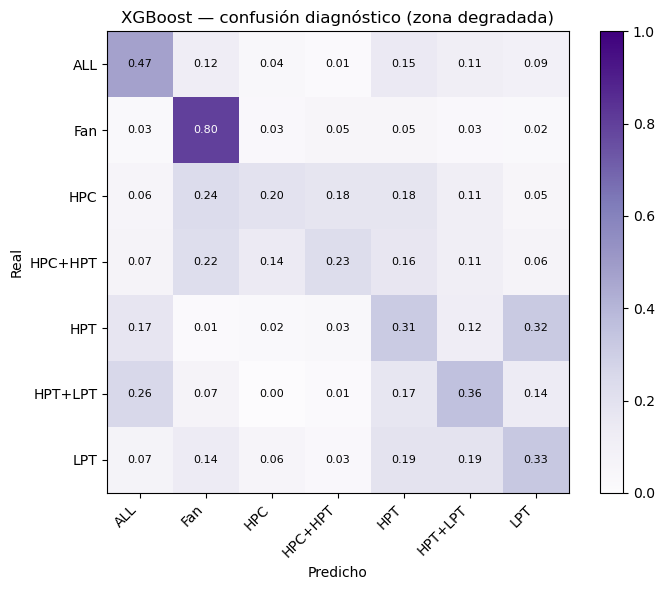

In [6]:
# Agrupado por familias + comparativa final
to_group=np.array([sorted(set(GROUP.values())).index(GROUP[c]) for c in CLASSES])
GC=sorted(set(GROUP.values()))
accg=accuracy_score(to_group[yte[deg]], to_group[pred[deg]])

print('==================== COMPARATIVA FINAL (zona degradada) ====================')
print(f'{"":22s} por ciclo | por motor | agrupado')
print(f'  CNN (Fase 6)          0.39    |   0.41    |   0.57')
print(f'  XGBoost (Fase 6c)     {accuracy_score(yte[deg],pred[deg]):.2f}    |   {pm_df.acierto.mean():.2f}    |   {accg:.2f}')

# matriz de confusion fina
cm=confusion_matrix(yte[deg],pred[deg],normalize='true')
fig,ax=plt.subplots(figsize=(7.5,6))
im=ax.imshow(cm,cmap='Purples',vmin=0,vmax=1)
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES,rotation=45,ha='right')
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j,i,f'{cm[i,j]:.2f}',ha='center',va='center',color='white' if cm[i,j]>0.5 else 'black',fontsize=8)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title('XGBoost — confusión diagnóstico (zona degradada)')
plt.colorbar(im); plt.tight_layout(); plt.savefig('confusion_xgb_diag.png',dpi=200,bbox_inches='tight'); plt.show()

In [7]:
import os as _os; _os.makedirs('modelos_diagnostico_xgb', exist_ok=True)
joblib.dump(clf, 'modelos_diagnostico_xgb/xgb_diagnostico.joblib')
joblib.dump({'FEATURES':FEATURES,'CLASSES':CLASSES,'GROUP':GROUP,'RUL_CAP':RUL_CAP},
            'modelos_diagnostico_xgb/config_xgb_diag.joblib')
print('Modelo guardado en modelos_diagnostico_xgb/: xgb_diagnostico.joblib + config_xgb_diag.joblib')

Modelo guardado en modelos_diagnostico_xgb/: xgb_diagnostico.joblib + config_xgb_diag.joblib


## 4. Resultados obtenidos y decisión final del componente de diagnóstico

| Modelo (zona degradada) | Por ciclo | **Por motor** | Agrupado |
|---|---|---|---|
| CNN (Fase 6) | 0,39 | 0,41 | 0,57 |
| **XGBoost (Fase 6c)** | 0,41 | **0,54** | 0,56 |

**XGBoost mejora donde importa: la métrica operativa (por motor) sube de 0,41 a 0,54** (21/39
motores), gracias a entrenar sobre ~2M de lecturas frente a las ~3.800 ventanas de la CNN. Con
honestidad estadística: son 5 motores de diferencia sobre 39, así que la decisión no descansa solo
en esa cifra sino en la convergencia de cuatro argumentos: coherencia con la prognosis (el tabular
gana en ambas tareas), **reparto más equilibrado del acierto entre clases** (la CNN concentraba su
acierto en el Fan; XGBoost mejora en las clases de turbina), **interpretabilidad** (la importancia
de features explica cada diagnóstico) y **despliegue más simple** (sin TensorFlow).

**El hallazgo más valioso:** el patrón de confusiones es **el mismo con ambos algoritmos** (Fan
distinguible, turbina/compresor confundidos entre sí). Dos modelos de naturaleza distinta
cometiendo los mismos errores en los mismos pares de clases = la dificultad es **física**, no de
arquitectura.

**Chequeo anti-fuga superado:** la feature más importante (P2_cyc_max) pesa solo 0,046 — el modelo
se apoya en muchas señales físicas repartidas, no en un atajo.

**Decisión final: XGBoost es el componente de diagnóstico del sistema PHM.** Queda validado
offline; su integración en el streaming (como señal de apoyo con confianza declarada, no como
decisión automática) se propone como trabajo futuro, dado que 0,54 no alcanza la fiabilidad de la
prognosis.